# 🗂️ Master-Summary — alle Selector-Sweeps über alle Datensätze

Aggregiert **jeden** Per-Run-Sweep aus `output/*_results.csv` (Schema mit `psnr_ho`)
in gemeinsame Grafiken. Ein Sweep = ein *Slice* (`<dataset>_s<start>_<N>f`), eine Zeile = ein Run.

Alle PSNR/SSIM/LPIPS hier sind die **fairen held-out Novel-View-Metriken** (`*_ho`,
feste Frame-Positionen) — nicht train-view (Methodik: `docs/FAIR_EVAL.md`).

**Wichtigste Grafik: PSNR ↔ Laufzeit** (Abschnitt 2, großes Subgrid — ein Panel pro Slice,
plus eine normalisierte Gesamt-Ansicht). Danach: Mapped-KFs, ATE, VRAM und ein
cross-dataset Selector-Ranking.

Einzel-Notebooks pro Slice: `scripts/analyze_sweep_<slice>_fair.ipynb`.


In [1]:
import re, math
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

REPO = Path('/home/philipp/Dokumente/Github/VINGS-Mono-BA')
OUT  = REPO / 'output'

# --- 5-Zeilen-Extrinsik-Sweep ist kein Selector-Sweep -> raus ---
EXCLUDE_SLICES = {'extr_sweep'}

frames = []
for csv in sorted(OUT.glob('*_results.csv')):
    slice_name = csv.name[:-len('_results.csv')]
    if slice_name in EXCLUDE_SLICES:
        continue
    df = pd.read_csv(csv)
    if 'psnr_ho' not in df.columns:
        continue
    df['slice'] = slice_name
    frames.append(df)

allr = pd.concat(frames, ignore_index=True)
# latest run per (slice, variant)
allr = (allr.sort_values('timestamp_start')
            .drop_duplicates(['slice', 'variant'], keep='last')
            .reset_index(drop=True))

ok   = allr[allr['status'] == 'OK'].copy()
fair = ok[ok['psnr_ho'].notna()].copy()   # nur Runs mit fairer Eval

print(f'Slices: {allr["slice"].nunique()}  |  Runs total: {len(allr)}  |  OK: {len(ok)}  |  fair (psnr_ho): {len(fair)}')
print('\nRuns je Dataset (fair):')
print(fair.groupby("dataset").size().sort_values(ascending=False).to_string())


Slices: 20  |  Runs total: 1159  |  OK: 925  |  fair (psnr_ho): 872

Runs je Dataset (fair):
dataset
amtown03       258
agz            188
HKairport03    143
AMvalley03     142
HKisland03     141


## 1) Übersicht — Slices & Selector-Gruppen

Globale Farbkodierung der Selector-Gruppen (gilt für alle folgenden Plots).


In [2]:
GROUPS = sorted(allr['group'].dropna().unique())
_cmap  = plt.cm.tab20.colors
GC = {g: _cmap[i % 20] for i, g in enumerate(GROUPS)}

# Slice-Reihenfolge: nach Dataset, dann Frame-Länge, dann Startframe
def _start(s):
    m = re.search(r'_s(\d+)_', s)
    return int(m.group(1)) if m else -1

slice_meta = (fair.groupby('slice')
                  .agg(dataset=('dataset','first'),
                       n_frames=('n_dataset_frames','first'),
                       n_runs=('variant','size'))
                  .reset_index())
slice_meta['start'] = slice_meta['slice'].map(_start)
slice_meta = slice_meta.sort_values(['dataset','n_frames','start']).reset_index(drop=True)
SLICES = slice_meta['slice'].tolist()
print(slice_meta.to_string(index=False))

legend_handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=GC[g],
                         markeredgecolor='k', markersize=9, label=g) for g in GROUPS]


                 slice     dataset  n_frames  n_runs  start
 AMvalley03_s2900_200f  AMvalley03       200      56   2900
  AMvalley03_s800_400f  AMvalley03       400      46    800
 AMvalley03_s4300_500f  AMvalley03       500      40   4300
HKairport03_s1600_200f HKairport03       200      58   1600
 HKairport03_s670_400f HKairport03       400      45    670
HKairport03_s2800_500f HKairport03       500      40   2800
 HKisland03_s2600_200f  HKisland03       200      57   2600
  HKisland03_s770_400f  HKisland03       400      43    770
 HKisland03_s2800_500f  HKisland03       500      41   2800
        agz_s2000_200f         agz       200      45   2000
        agz_s5600_200f         agz       200      35   5600
        agz_s7950_200f         agz       200      37   7950
        agz_s2675_400f         agz       400      36   2675
        agz_s9000_400f         agz       400      35   9000
            s3100_200f    amtown03       200      56     -1
    amtown03_s400_200f    amtown03      

## 2) ⭐ PSNR ↔ Laufzeit — großes Subgrid (ein Panel pro Slice)

Die zentrale Grafik. Jedes Panel ist ein Sweep: held-out PSNR (y) gegen Laufzeit in
Minuten (x), jeder Punkt ein Selector-Run, Farbe = Selector-Gruppe. Rote gestrichelte
Linie = Pareto-Front (hoch & links = gut). `mapskip`/`skip_no_filter` sind als graue
Referenzpunkte mit drin (keine Selector-Algos).


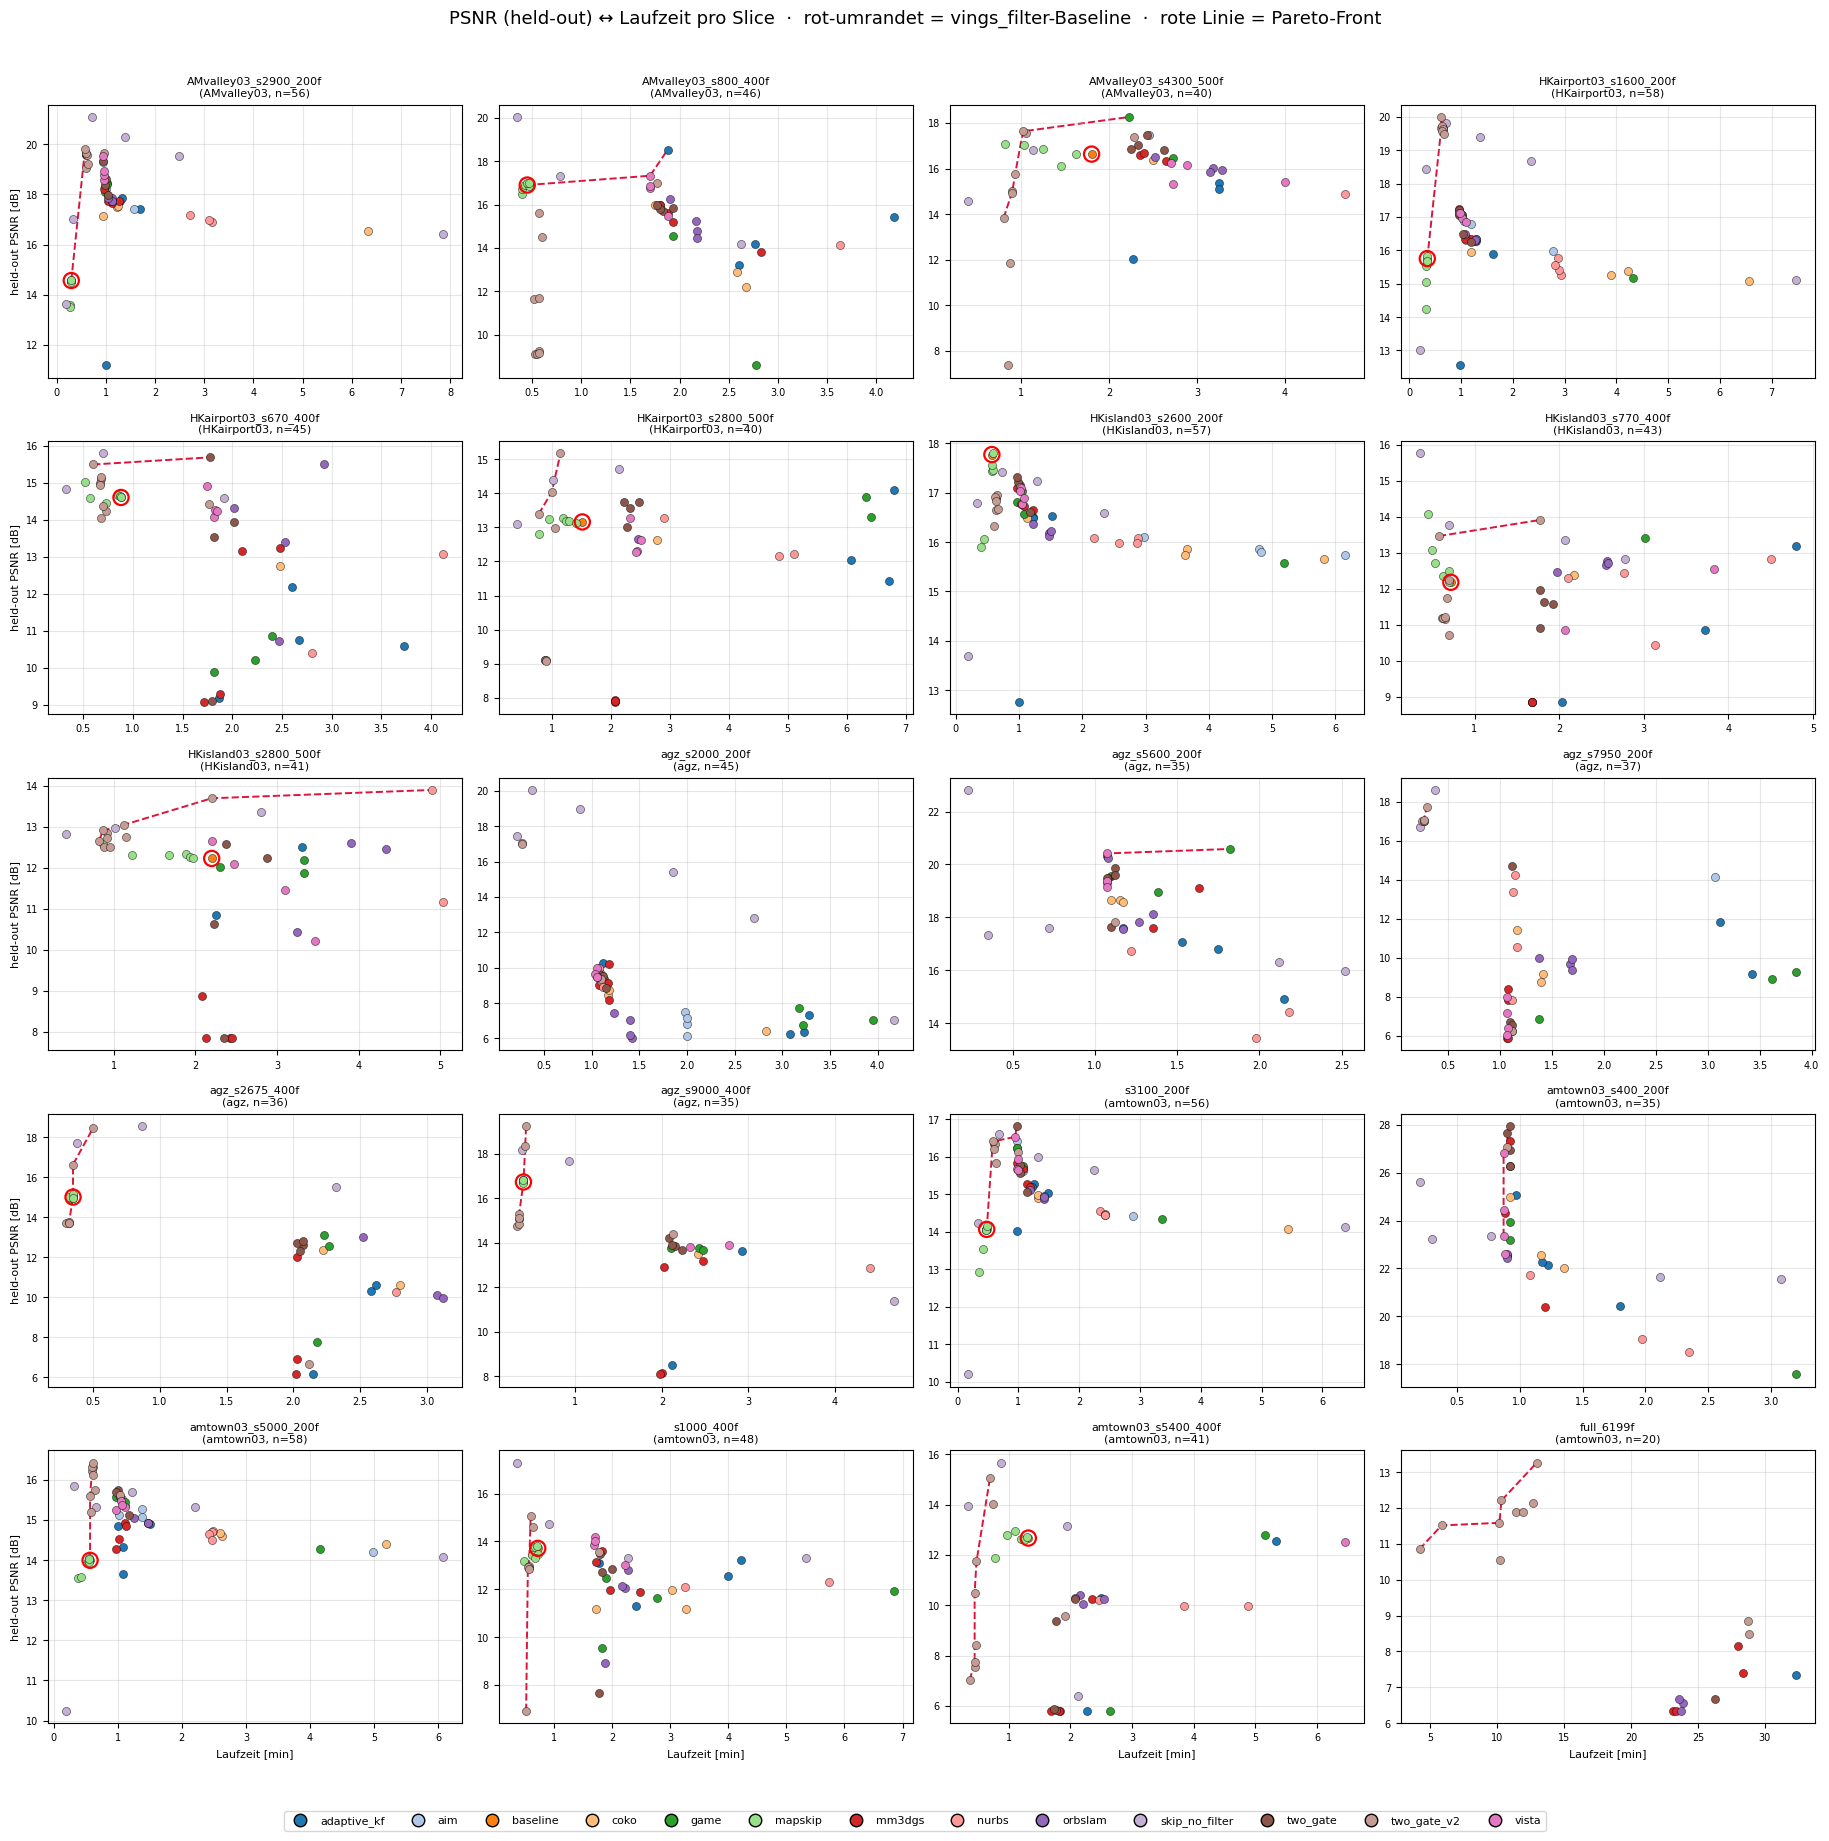

In [3]:
def pareto(sub, x='duration_min', y='psnr_ho'):
    s = sub.dropna(subset=[x,y]).sort_values(x)
    best=-np.inf; keep=[]
    for _, r in s.iterrows():
        if r[y] > best:
            keep.append(r); best = r[y]
    return pd.DataFrame(keep)

ncols = 4
nrows = math.ceil(len(SLICES) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.6, nrows*3.6))
axes = np.atleast_1d(axes).ravel()

for ax, sl in zip(axes, SLICES):
    sub = fair[fair['slice'] == sl]
    for g in GROUPS:
        s2 = sub[sub['group'] == g]
        if len(s2):
            ax.scatter(s2['duration_min'], s2['psnr_ho'], s=34, color=GC[g],
                       edgecolor='black', linewidth=0.3, zorder=2)
    pf = pareto(sub[~sub['group'].isin(['mapskip','skip_no_filter'])])
    if len(pf):
        ax.plot(pf['duration_min'], pf['psnr_ho'], color='crimson', lw=1.4, ls='--', zorder=1)
    # baseline marker
    bl = sub[sub['group'] == 'baseline']
    if len(bl):
        ax.scatter(bl['duration_min'], bl['psnr_ho'], s=120, facecolors='none',
                   edgecolors='red', linewidths=1.6, zorder=3)
    ds = sub['dataset'].iloc[0] if len(sub) else ''
    ax.set_title(f'{sl}\n({ds}, n={len(sub)})', fontsize=8)
    ax.grid(alpha=0.3); ax.tick_params(labelsize=7)

for ax in axes[len(SLICES):]:
    ax.axis('off')
for ax in axes[-ncols:]:
    ax.set_xlabel('Laufzeit [min]', fontsize=8)
for r in range(nrows):
    axes[r*ncols].set_ylabel('held-out PSNR [dB]', fontsize=8)

fig.legend(handles=legend_handles, loc='lower center', ncol=len(GROUPS),
           fontsize=8, bbox_to_anchor=(0.5, -0.015))
fig.suptitle('PSNR (held-out) ↔ Laufzeit pro Slice  ·  rot-umrandet = vings_filter-Baseline  ·  rote Linie = Pareto-Front',
             fontsize=13, y=1.0)
fig.tight_layout(rect=[0,0.02,1,0.99])
plt.show()


### 2b) Normalisierte Gesamt-Ansicht — alle Runs in einer Grafik

Absolute PSNR/Laufzeit unterscheiden sich stark je Datensatz. Hier deshalb **relativ zur
`vings_filter`-Baseline desselben Slice**: ΔPSNR = `psnr_ho − baseline_psnr` (y) gegen
Laufzeit-Verhältnis `duration / baseline_duration` (x). So liegen alle Slices auf
gemeinsamem Maßstab in *einer* Grafik. Punkt oben-links = schneller **und** besser als die
Baseline. Marker-Form = Datensatz, Farbe = Selector-Gruppe.


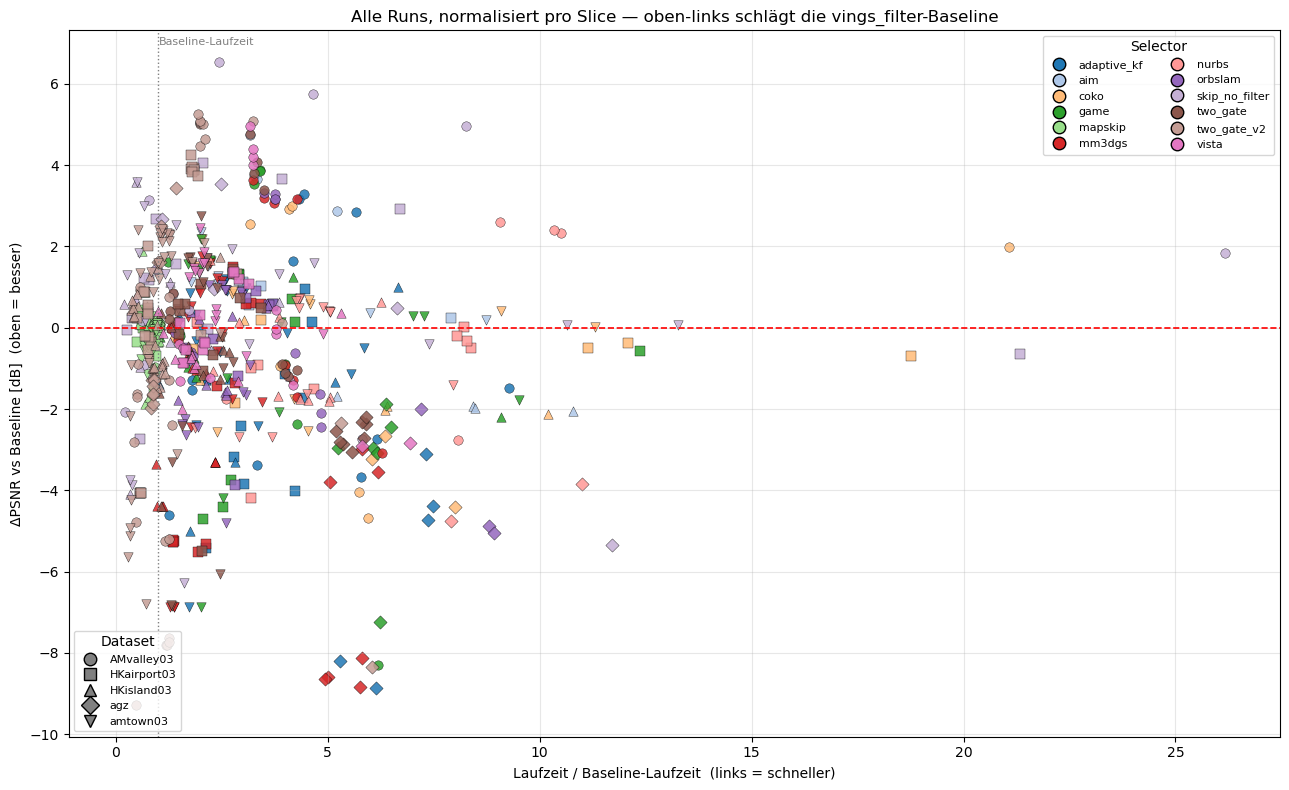

In [4]:
base_psnr = fair[fair['group']=='baseline'].set_index('slice')['psnr_ho'].to_dict()
base_dur  = fair[fair['group']=='baseline'].set_index('slice')['duration_min'].to_dict()

f2 = fair[~fair['group'].isin(['baseline'])].copy()
f2 = f2[f2['slice'].map(lambda s: s in base_psnr)].copy()
f2['dpsnr']    = f2.apply(lambda r: r['psnr_ho'] - base_psnr[r['slice']], axis=1)
f2['dur_ratio']= f2.apply(lambda r: r['duration_min'] / base_dur[r['slice']]
                          if base_dur[r['slice']] else np.nan, axis=1)

DATASETS = sorted(f2['dataset'].unique())
MARKERS  = ['o','s','^','D','v','P','X','*','<','>']
DM = {d: MARKERS[i % len(MARKERS)] for i, d in enumerate(DATASETS)}

fig, ax = plt.subplots(figsize=(13, 8))
for g in GROUPS:
    if g in ('baseline',): continue
    for d in DATASETS:
        s2 = f2[(f2['group']==g) & (f2['dataset']==d)]
        if len(s2):
            ax.scatter(s2['dur_ratio'], s2['dpsnr'], s=46, color=GC[g],
                       marker=DM[d], edgecolor='black', linewidth=0.3, alpha=0.85)
ax.axhline(0, color='red', lw=1.2, ls='--')
ax.axvline(1, color='gray', lw=1.0, ls=':')
ax.text(1.01, ax.get_ylim()[1]*0.95, 'Baseline-Laufzeit', color='gray', fontsize=8)
ax.set_xlabel('Laufzeit / Baseline-Laufzeit  (links = schneller)')
ax.set_ylabel('ΔPSNR vs Baseline [dB]  (oben = besser)')
ax.set_title('Alle Runs, normalisiert pro Slice — oben-links schlägt die vings_filter-Baseline')
ax.grid(alpha=0.3)

leg1 = ax.legend(handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor=GC[g],
                 markeredgecolor='k', markersize=9, label=g) for g in GROUPS if g!='baseline'],
                 title='Selector', loc='upper right', fontsize=8, ncol=2)
ax.add_artist(leg1)
ax.legend(handles=[Line2D([0],[0], marker=DM[d], color='w', markerfacecolor='gray',
          markeredgecolor='k', markersize=9, label=d) for d in DATASETS],
          title='Dataset', loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()


## 3) Weitere Gesamt-Grafiken — Subgrid

Alle Runs zusammen: (a) PSNR↔Mapped-KFs, (b) Laufzeit↔Mapped-KFs,
(c) ATE↔PSNR (Tracking vs Mapping), (d) Peak-VRAM pro Selector-Gruppe.


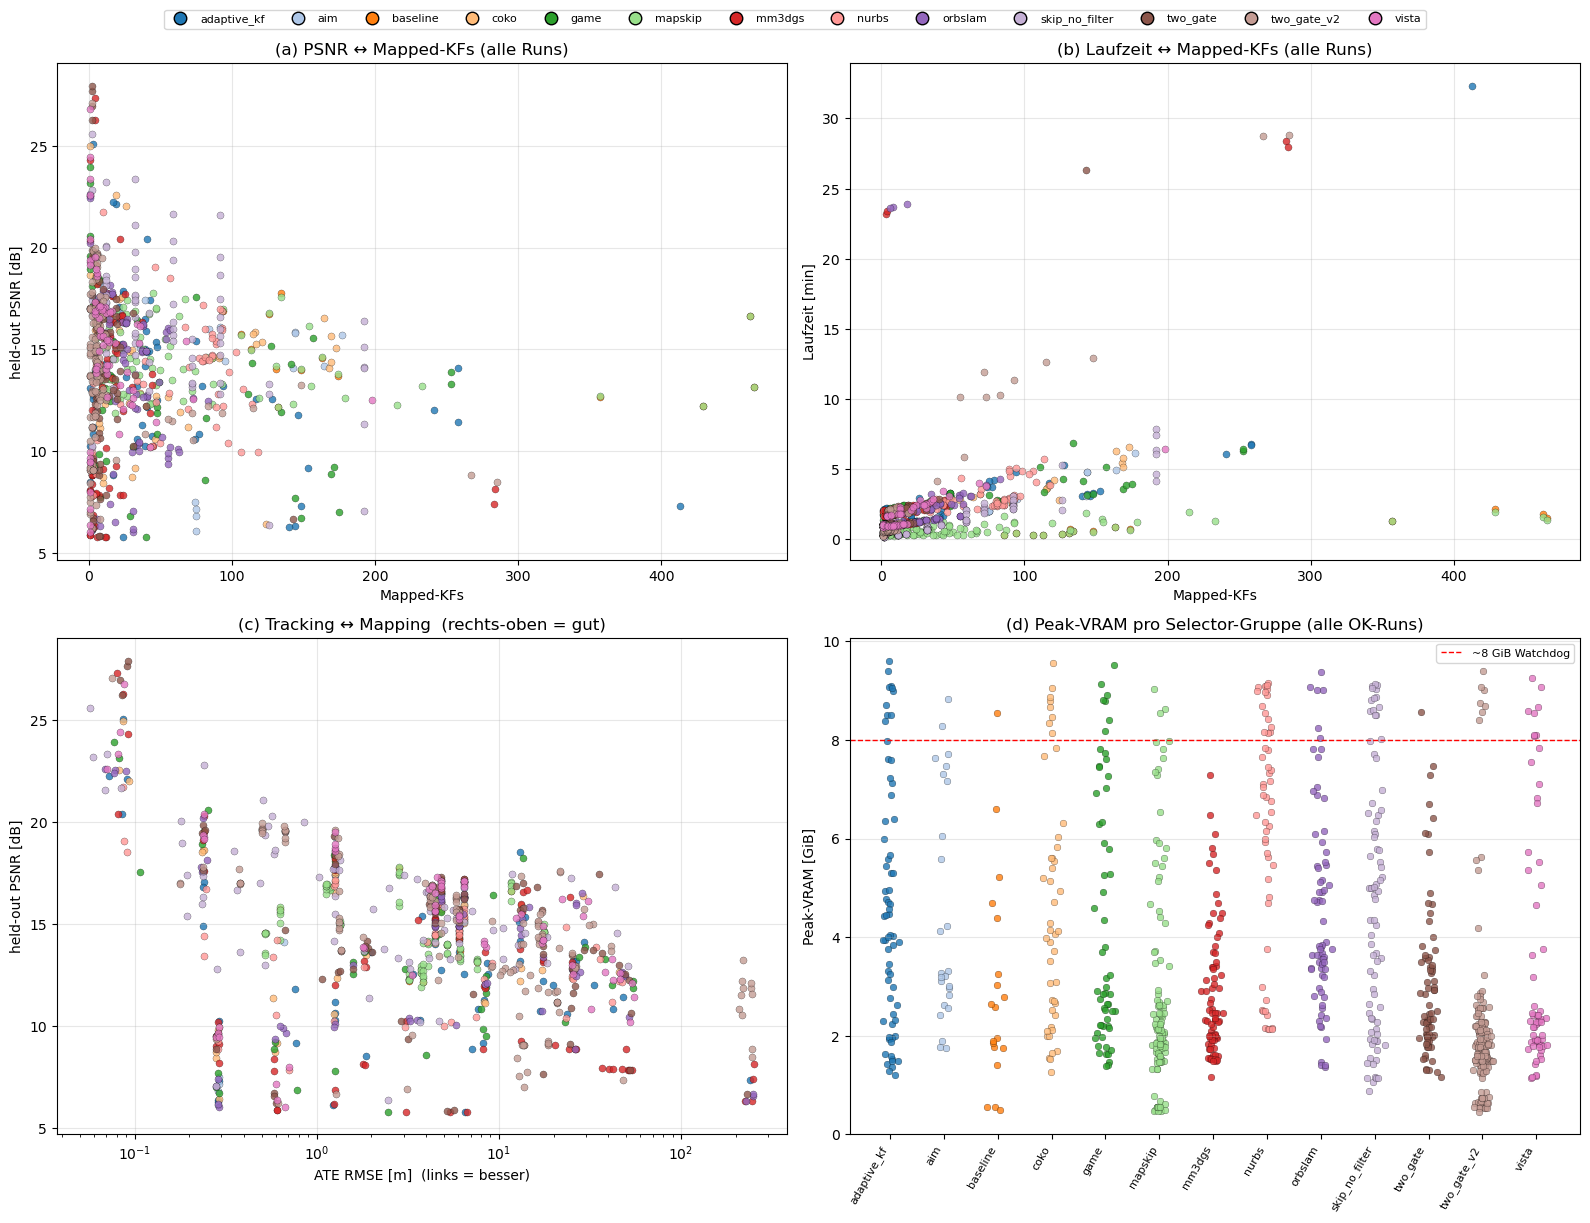

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) PSNR vs Mapped-KFs
ax = axes[0,0]
for g in GROUPS:
    s2 = fair[fair['group']==g]
    ax.scatter(s2['n_mapped'], s2['psnr_ho'], s=26, color=GC[g], edgecolor='k', linewidth=0.2, alpha=0.8)
ax.set_xlabel('Mapped-KFs'); ax.set_ylabel('held-out PSNR [dB]')
ax.set_title('(a) PSNR ↔ Mapped-KFs (alle Runs)'); ax.grid(alpha=0.3)

# (b) Laufzeit vs Mapped-KFs
ax = axes[0,1]
for g in GROUPS:
    s2 = fair[fair['group']==g]
    ax.scatter(s2['n_mapped'], s2['duration_min'], s=26, color=GC[g], edgecolor='k', linewidth=0.2, alpha=0.8)
ax.set_xlabel('Mapped-KFs'); ax.set_ylabel('Laufzeit [min]')
ax.set_title('(b) Laufzeit ↔ Mapped-KFs (alle Runs)'); ax.grid(alpha=0.3)

# (c) ATE vs PSNR
ax = axes[1,0]
sc = fair.dropna(subset=['ate_rmse_m'])
for g in GROUPS:
    s2 = sc[sc['group']==g]
    ax.scatter(s2['ate_rmse_m'], s2['psnr_ho'], s=26, color=GC[g], edgecolor='k', linewidth=0.2, alpha=0.8)
ax.set_xlabel('ATE RMSE [m]  (links = besser)'); ax.set_ylabel('held-out PSNR [dB]')
ax.set_title('(c) Tracking ↔ Mapping  (rechts-oben = gut)'); ax.grid(alpha=0.3)
if len(sc):
    ax.set_xscale('log')

# (d) Peak-VRAM pro Gruppe (Strip)
ax = axes[1,1]
for i, g in enumerate(GROUPS):
    s2 = ok[ok['group']==g].dropna(subset=['peak_vram_mib'])
    if len(s2):
        x = np.random.normal(i, 0.07, len(s2))
        ax.scatter(x, s2['peak_vram_mib']/1024.0, s=24, color=GC[g], edgecolor='k', linewidth=0.2, alpha=0.8)
ax.axhline(8.0, color='red', ls='--', lw=1, label='~8 GiB Watchdog')
ax.set_xticks(range(len(GROUPS))); ax.set_xticklabels(GROUPS, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Peak-VRAM [GiB]'); ax.set_title('(d) Peak-VRAM pro Selector-Gruppe (alle OK-Runs)')
ax.grid(alpha=0.3, axis='y'); ax.legend(fontsize=8)

fig.legend(handles=legend_handles, loc='upper center', ncol=len(GROUPS), fontsize=8, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(); plt.show()


## 4) Cross-Dataset-Ranking der Selektoren

Da absolute Werte je Datensatz variieren, wird pro Slice **relativ zur Baseline**
gemittelt: mittleres ΔPSNR (held-out) und mittleres Laufzeit-Verhältnis über alle
Slices, in denen die Gruppe vorkommt. Rechts-oben (mehr PSNR, weniger Laufzeit) = bestes
Gesamtprofil. Reine Mapping-Drosseln (`mapskip`/`skip_no_filter`) als Referenz dunkler.


         group  dpsnr_mean  dpsnr_std  durratio_mean  n_slices  n_runs
           aim    0.992775   1.924066       4.659319         5      20
skip_no_filter    0.768569   2.434383       3.182079        15      62
         vista    0.315451   1.686181       2.560852        14      49
       mapskip   -0.089333   0.481115       0.879348        15      89
   two_gate_v2   -0.130729   3.117063       1.175630        15     128
       orbslam   -0.531565   1.942120       3.154014        14      51
      two_gate   -0.558730   2.415064       2.668091        15      60
          coko   -0.616876   2.057956       6.001847        13      33
         nurbs   -0.716113   1.741176       5.316795        15      39
          game   -0.844689   2.775411       3.871777        15      45
   adaptive_kf   -1.551551   2.681484       3.745371        15      51
        mm3dgs   -2.115134   3.200788       2.723278        15      58


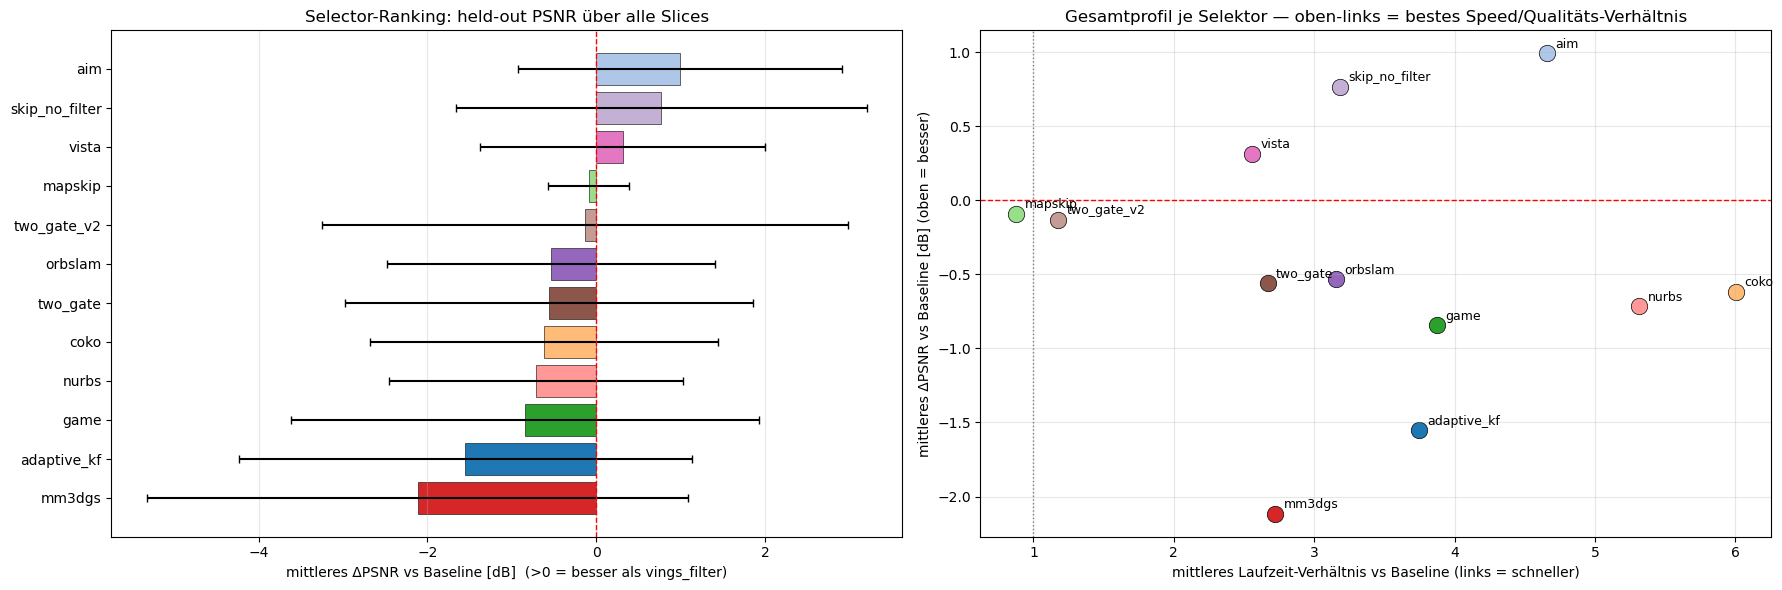

In [6]:
agg = (f2.groupby('group')
          .agg(dpsnr_mean=('dpsnr','mean'),
               dpsnr_std =('dpsnr','std'),
               durratio_mean=('dur_ratio','mean'),
               n_slices=('slice','nunique'),
               n_runs=('variant','size'))
          .reset_index()
          .sort_values('dpsnr_mean', ascending=False))
print(agg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar: mean ΔPSNR vs baseline
ax = axes[0]
order = agg.sort_values('dpsnr_mean')
ax.barh(order['group'], order['dpsnr_mean'],
        xerr=order['dpsnr_std'].fillna(0), color=[GC[g] for g in order['group']],
        edgecolor='black', linewidth=0.4, capsize=3)
ax.axvline(0, color='red', ls='--', lw=1)
ax.set_xlabel('mittleres ΔPSNR vs Baseline [dB]  (>0 = besser als vings_filter)')
ax.set_title('Selector-Ranking: held-out PSNR über alle Slices'); ax.grid(alpha=0.3, axis='x')

# Scatter: dpsnr vs duration-ratio
ax = axes[1]
for _, r in agg.iterrows():
    ax.scatter(r['durratio_mean'], r['dpsnr_mean'], s=140, color=GC[r['group']],
               edgecolor='black', linewidth=0.5)
    ax.annotate(r['group'], (r['durratio_mean'], r['dpsnr_mean']),
                xytext=(6,4), textcoords='offset points', fontsize=9)
ax.axhline(0, color='red', ls='--', lw=1); ax.axvline(1, color='gray', ls=':', lw=1)
ax.set_xlabel('mittleres Laufzeit-Verhältnis vs Baseline (links = schneller)')
ax.set_ylabel('mittleres ΔPSNR vs Baseline [dB] (oben = besser)')
ax.set_title('Gesamtprofil je Selektor — oben-links = bestes Speed/Qualitäts-Verhältnis')
ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 5) Bestes Setup pro Slice

Pro Slice der Run mit höchstem held-out PSNR (Selektoren only, ohne mapskip/skip_no_filter),
plus die Baseline zum Vergleich.


In [7]:
rows = []
for sl in SLICES:
    sub = fair[fair['slice']==sl]
    sel = sub[~sub['group'].isin(['mapskip','skip_no_filter','baseline'])]
    if not len(sel):
        continue
    best = sel.loc[sel['psnr_ho'].idxmax()]
    bl   = sub[sub['group']=='baseline']
    bl_p = bl['psnr_ho'].iloc[0] if len(bl) else np.nan
    rows.append(dict(slice=sl, dataset=best['dataset'],
                     best_variant=best['variant'], best_psnr=round(best['psnr_ho'],2),
                     best_dur_min=round(best['duration_min'],2),
                     baseline_psnr=round(bl_p,2) if bl_p==bl_p else np.nan,
                     d_vs_base=round(best['psnr_ho']-bl_p,2) if bl_p==bl_p else np.nan,
                     ate_m=round(best['ate_rmse_m'],2) if pd.notna(best['ate_rmse_m']) else np.nan))
best_df = pd.DataFrame(rows)
import IPython.display as D
D.display(best_df)
print('\nWie oft stellt jede Selector-Gruppe den Slice-Sieger?')
win_groups = fair.drop_duplicates('variant').set_index('variant')['group'].to_dict()
print(best_df['best_variant'].map(lambda v: win_groups.get(v, '?')).value_counts().to_string())


,slice,dataset,best_variant,best_psnr,best_dur_min,baseline_psnr,d_vs_base,ate_m
0,AMvalley03_s2900_200f,AMvalley03,two_gate_v2_strict,19.82,0.58,14.56,5.25,0.67
1,AMvalley03_s800_400f,AMvalley03,adaptive_kf_sens3,18.54,1.88,16.90,1.64,13.13
2,AMvalley03_s4300_500f,AMvalley03,game_th070,18.26,2.22,16.64,1.63,13.61
3,HKairport03_s1600_200f,HKairport03,two_gate_v2_strict,19.99,0.62,15.75,4.24,0.50
4,HKairport03_s670_400f,HKairport03,two_gate_b2only,15.68,1.78,14.60,1.08,17.37
5,HKairport03_s2800_500f,HKairport03,two_gate_v2_a3_loose_b1gps,15.17,1.15,13.16,2.01,9.15
6,HKisland03_s2600_200f,HKisland03,two_gate_strict,17.32,0.97,17.77,-0.46,4.80
7,HKisland03_s770_400f,HKisland03,two_gate_v2_a3off,13.91,1.78,12.17,1.73,41.53
8,HKisland03_s2800_500f,HKisland03,nurbs_orb400,13.90,4.90,12.23,1.67,34.03
9,agz_s2000_200f,agz,two_gate_v2_a3_loose_b1gps,17.04,0.27,NaN,NaN,0.18



Wie oft stellt jede Selector-Gruppe den Slice-Sieger?
best_variant
two_gate_v2    12
two_gate        4
game            2
adaptive_kf     1
nurbs           1
